In [40]:
include("../necklaces.jl")
using BenchmarkTools, Plots, ProgressMeter, Distributions

In [188]:
m = 40
p = 2
n = p^m
logP = log_lumped_transition_kernel(n, 2)
P = softmax(logP, dims=2)
logQ = approx_log_lumped_transition_kernel(n, 2)
Q = softmax(logQ, dims=2)
stationary_dist = lumped_stationary_distribution(n, 2);

In [189]:
maximum(sum.(abs.(P - Q))/2)

0.12500000000000003

In [190]:
2.0 ^(-(p-1))

0.5

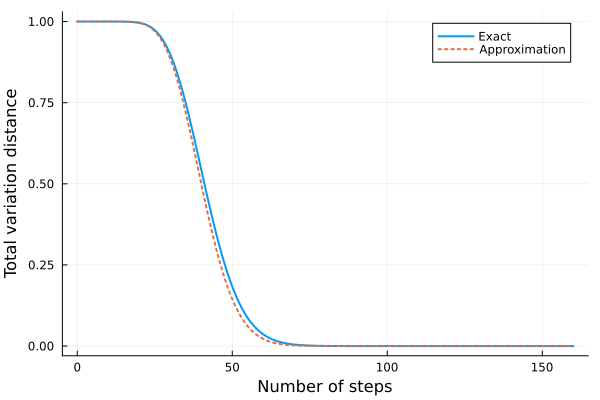

In [191]:
distribution = zeros(m+1)
distribution[1] = 1
TV_dist = [sum(abs.(stationary_dist.-distribution))/2]
Pt = P'
reps = m*p*2
for i in 1:reps
    distribution = Pt * distribution
    push!(TV_dist, sum(abs.(stationary_dist.-distribution))/2)
end
ts = 0:reps
approx = ones(reps+1)
approx2 = ones(reps+1)
for t in 1:reps
    nbin = NegativeBinomial(t, 1-1/p)
    approx[t+1] = cdf(nbin, m-1)
end
plt = plot(ts, TV_dist, label="Exact", linewidth = 2)
plot!(plt, ts, approx, label="Approximation",linewidth = 2, linestyle = :dot)
xlabel!(plt, "Number of steps")
ylabel!(plt, "Total variation distance")

In [185]:
maximum(TV_dist .- approx)

0.0897116635527773

In [186]:
maximum(@. TV_dist - approx + 2 * n / 2^(n/2))

0.0897116635527773

In [187]:
minimum(@. TV_dist - approx + 2 * n / 2^(n/2))

1.504632769052528e-36